### 1. Gerekli Kütüphanelerin İçe Aktarılması
Veri analizi (EDA) ve görselleştirme işlemleri için kullanacağımız temel Python kütüphanelerini içe aktarıyoruz.
Ayrıca notebook'un çalışma dizinini projenin ana klasörüne (`DataMining/`) ayarlıyoruz.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')

# Notebook notebooks/ klasöründen çalıştırıldığı için çalışma dizinini
# projenin ana klasörüne çekiyoruz.
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

print('Çalışma dizini:', os.getcwd())

Çalışma dizini: /Users/ahmetmertkadioglu/Desktop/DataMining


### 2. Küçük / Orta Boyutlu CSV Dosyalarının Okunması
Bellek dostu okuma için sütun veri tiplerini (`dtype`) optimize ediyoruz.
`studentVle.csv` (433 MB) çok büyük olduğu için ayrı bir hücrede `chunksize` ile okunacak.

In [2]:
# --- Küçük / Orta tablolar (doğrudan okuma) ---

courses = pd.read_csv(
    'data/raw/courses.csv'
)

assessments = pd.read_csv(
    'data/raw/assessments.csv'
)

vle = pd.read_csv(
    'data/raw/vle.csv'
)

student_info = pd.read_csv(
    'data/raw/studentInfo.csv',
    dtype={
        'id_student': 'int32',
        'gender': 'category',
        'region': 'category',
        'highest_education': 'category',
        'imd_band': 'category',
        'age_band': 'category',
        'disability': 'category',
        'final_result': 'category'
    }
)

student_registration = pd.read_csv(
    'data/raw/studentRegistration.csv',
    dtype={
        'id_student': 'int32'
    }
)

student_assessment = pd.read_csv(
    'data/raw/studentAssessment.csv',
    dtype={
        'id_student': 'int32',
        'id_assessment': 'int32',
        'is_banked': 'int8'
    }
)

print('Küçük/orta tablolar başarıyla yüklendi.')

Küçük/orta tablolar başarıyla yüklendi.


### 3. Büyük Tablonun Okunması: `studentVle.csv` (433 MB)
`studentVle.csv` dosyası çok büyük olduğu için `chunksize=500_000` ile
parça parça okunup birleştiriliyor. Bu yöntem kernel çökmesini önler.

In [3]:
print('studentVle.csv okunuyor, lütfen bekleyin...')

chunks = []
for chunk in pd.read_csv(
    'data/raw/studentVle.csv',
    chunksize=500_000,
    dtype={
        'id_student': 'int32',
        'id_site': 'int32',
        'sum_click': 'int32'
    }
):
    chunks.append(chunk)

student_vle = pd.concat(chunks, ignore_index=True)
del chunks  # Belleği serbest bırak

print(f'studentVle yüklendi. Shape: {student_vle.shape}')

studentVle.csv okunuyor, lütfen bekleyin...
studentVle yüklendi. Shape: (10655280, 6)


### 4. Tüm Tabloların İncelenmesi
Her tablonun adı, boyutu (satır x sütun), sütun isimleri / veri tipleri ve ilk 5 satırı yazdırılıyor.

In [4]:
dataframes = {
    'student_info': student_info,
    'student_assessment': student_assessment,
    'student_vle': student_vle,
    'assessments': assessments,
    'courses': courses,
    'student_registration': student_registration,
    'vle': vle
}

for name, df in dataframes.items():
    print('=' * 55)
    print(f'  TABLO ADI : {name}')
    print('=' * 55)
    print(f'  Shape     : {df.shape[0]} satır  x  {df.shape[1]} sütun')
    print()
    print('  Sütun İsimleri ve Veri Tipleri:')
    print(df.dtypes.to_string())
    print()
    print('  İlk 5 Satır:')
    display(df.head())
    print('\n')

  TABLO ADI : student_info
  Shape     : 32593 satır  x  12 sütun

  Sütun İsimleri ve Veri Tipleri:
code_module               object
code_presentation         object
id_student                 int32
gender                  category
region                  category
highest_education       category
imd_band                category
age_band                category
num_of_prev_attempts       int64
studied_credits            int64
disability              category
final_result            category

  İlk 5 Satır:


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass




  TABLO ADI : student_assessment
  Shape     : 173912 satır  x  5 sütun

  Sütun İsimleri ve Veri Tipleri:
id_assessment       int32
id_student          int32
date_submitted      int64
is_banked            int8
score             float64

  İlk 5 Satır:


,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0




  TABLO ADI : student_vle
  Shape     : 10655280 satır  x  6 sütun

  Sütun İsimleri ve Veri Tipleri:
code_module          object
code_presentation    object
id_student            int32
id_site               int32
date                  int64
sum_click             int32

  İlk 5 Satır:


...

,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268
3,BBB,2014J,262
4,BBB,2013B,240




  TABLO ADI : student_registration
  Shape     : 32593 satır  x  5 sütun

  Sütun İsimleri ve Veri Tipleri:
code_module             object
code_presentation       object
id_student               int32
date_registration      float64
date_unregistration    float64

  İlk 5 Satır:


,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,NaN
1,AAA,2013J,28400,-53.0,NaN
2,AAA,2013J,30268,-92.0,12.0
3,AAA,2013J,31604,-52.0,NaN
4,AAA,2013J,32885,-176.0,NaN




  TABLO ADI : vle
  Shape     : 6364 satır  x  6 sütun

  Sütun İsimleri ve Veri Tipleri:
id_site                int64
code_module           object
code_presentation     object
activity_type         object
week_from            float64
week_to              float64

  İlk 5 Satır:


,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,NaN,NaN
1,546712,AAA,2013J,oucontent,NaN,NaN
2,546998,AAA,2013J,resource,NaN,NaN
3,546888,AAA,2013J,url,NaN,NaN
4,547035,AAA,2013J,resource,NaN,NaN


### 5. Eksik Veri Özeti (Tablo ve Kolon Bazında)
Her tablo için kolon bazında:
- `eksik_sayi`: eksik (NaN) gözlem adedi
- `eksik_yuzde`: eksik gözlemlerin yüzde oranı

Ayrıca her tablo için toplam eksik hücre sayısı ve yüzdesini de (tablo bazında) özetliyoruz.

In [9]:
# Eksik veri özetlerini üret (kolon bazında) ve stilize şekilde göster

def missing_summary_by_column(df: pd.DataFrame) -> pd.DataFrame:
    missing_count = df.isna().sum()
    missing_pct = (missing_count / len(df) * 100) if len(df) else (missing_count * 0)

    out = (
        pd.DataFrame({
            'kolon': missing_count.index,
            'eksik_sayi': missing_count.values,
            'eksik_yuzde': missing_pct.values
        })
        .sort_values(['eksik_sayi', 'eksik_yuzde'], ascending=False)
        .reset_index(drop=True)
    )
    return out

# 1) Kolon bazında (tablo + kolon) birleşik özet DF
missing_by_table_col_parts = []
for table_name, df in dataframes.items():
    summ = missing_summary_by_column(df)
    summ.insert(0, 'tablo', table_name)
    missing_by_table_col_parts.append(summ)

missing_by_table_col = (
    pd.concat(missing_by_table_col_parts, ignore_index=True)
    .sort_values(['eksik_sayi', 'eksik_yuzde'], ascending=False)
    .reset_index(drop=True)
)

# 2) Tablo bazında genel özet DF
missing_overall = []
for table_name, df in dataframes.items():
    missing_cells = int(df.isna().sum().sum())
    total_cells = int(df.shape[0] * df.shape[1])
    pct = (missing_cells / total_cells * 100) if total_cells else 0.0

    missing_overall.append({
        'tablo': table_name,
        'satir': int(df.shape[0]),
        'sutun': int(df.shape[1]),
        'eksik_hucre_sayi': missing_cells,
        'eksik_hucre_yuzde': pct
    })

missing_overall_df = (
    pd.DataFrame(missing_overall)
    .sort_values('eksik_hucre_yuzde', ascending=False)
    .reset_index(drop=True)
)

def pretty_display(df: pd.DataFrame, pct_col: str | None = None):
    """Jinja2 yoksa .style çalışmaz; bu durumda normal display kullan."""
    try:
        styler = df.style
        if pct_col is not None:
            styler = (
                styler
                .format({pct_col: '{:.2f}%'})
                .background_gradient(subset=[pct_col], cmap='viridis')
            )
        display(styler)
    except Exception:
        # En güvenli fallback
        display(df)

print('Tablo bazında genel eksik hücre özeti:')
pretty_display(missing_overall_df, pct_col='eksik_hucre_yuzde')

print('\nKolon bazında eksik değer özeti (yalnız eksik içeren kolonlar):')
missing_nonzero = missing_by_table_col[missing_by_table_col['eksik_sayi'] > 0].copy()

if missing_nonzero.empty:
    print('Hiçbir tabloda eksik değer yok.')
else:
    pretty_display(missing_nonzero, pct_col='eksik_yuzde')


Tablo bazında genel eksik hücre özeti:


,tablo,satir,sutun,eksik_hucre_sayi,eksik_hucre_yuzde
0,vle,6364,6,10486,27.461764
1,student_registration,32593,5,22566,13.847145
2,assessments,206,6,11,0.889968
3,student_info,32593,12,1111,0.284059
4,student_assessment,173912,5,173,0.019895
5,student_vle,10655280,6,0,0.000000
6,courses,22,3,0,0.000000



Kolon bazında eksik değer özeti (yalnız eksik içeren kolonlar):


,tablo,kolon,eksik_sayi,eksik_yuzde
0,student_registration,date_unregistration,22521,69.097659
1,vle,week_from,5243,82.385292
2,vle,week_to,5243,82.385292
3,student_info,imd_band,1111,3.408707
4,student_assessment,score,173,0.099476
5,student_registration,date_registration,45,0.138066
6,assessments,date,11,5.339806


### 6. Eksik Veri Isı Haritası (Seaborn Heatmap)
Eksik değer içeren tablolar için eksik veri desenini görselleştiriyoruz.

- `cmap='viridis'`
- `ybar=False`: seaborn tarafında renk çubuğunu kapatmak için `cbar=False` kullanıyoruz.

Not: Çok büyük tablolar için (örn. `student_vle`) heatmap’in hızlı ve okunabilir olması adına satır örneklemesi uygulanır.

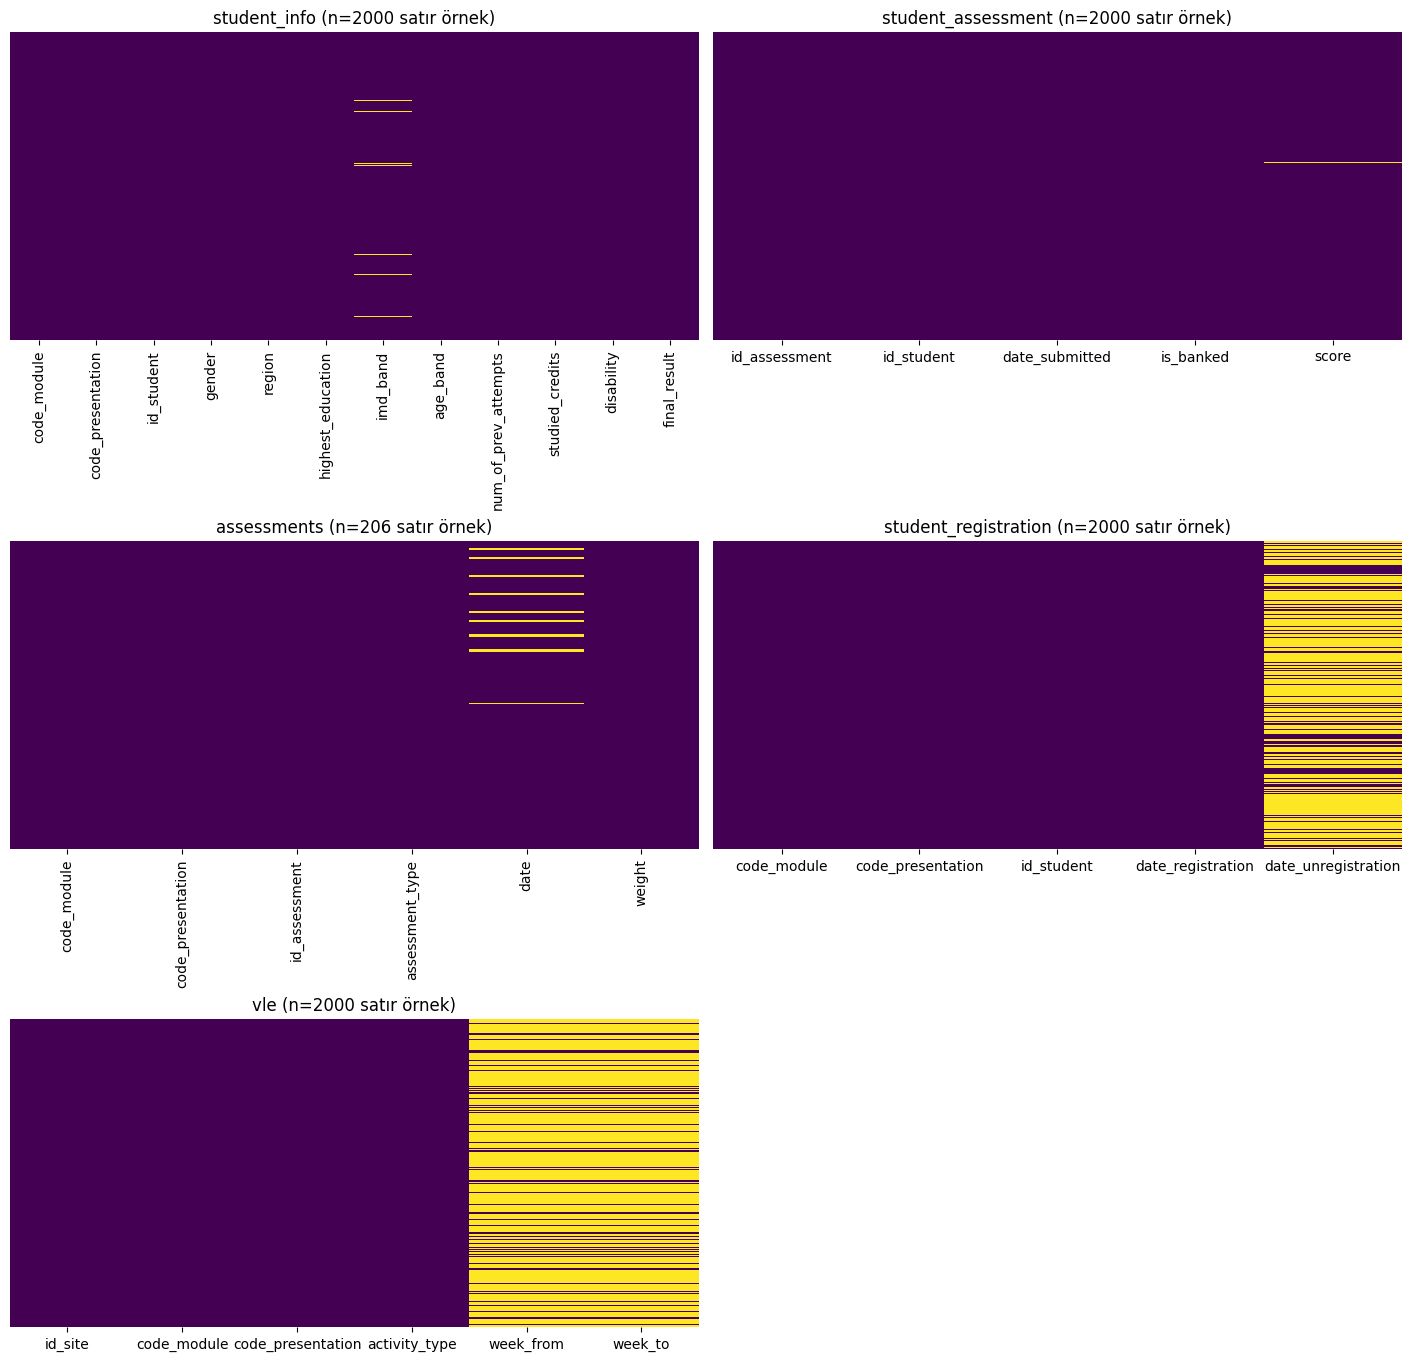

Heatmap kaydedildi: visuals/eda/eksik_veri_heatmap.png


In [10]:
# Eksik veri içeren tablolar için heatmap üret ve kaydet

import math

missing_tables = [name for name, df in dataframes.items() if df.isna().any().any()]

if len(missing_tables) == 0:
    print('Eksik değer içeren tablo yok; heatmap oluşturulmadı.')
else:
    os.makedirs('visuals/eda', exist_ok=True)

    # Heatmap performansı/okunabilirlik için satır örnekleme
    max_rows_for_heatmap = 2000

    n = len(missing_tables)
    ncols = 2 if n > 1 else 1
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(14, 4.5 * nrows),
        constrained_layout=True
    )

    axes_arr = np.array(axes).reshape(-1)

    for idx, table_name in enumerate(missing_tables):
        ax = axes_arr[idx]
        df = dataframes[table_name]

        df_plot = df
        if len(df_plot) > max_rows_for_heatmap:
            df_plot = df_plot.sample(max_rows_for_heatmap, random_state=42)

        sns.heatmap(
            df_plot.isna(),
            cmap='viridis',
            cbar=False,      # ybar=False karşılığı
            yticklabels=False,
            xticklabels=True,
            ax=ax
        )
        ax.set_title(f"{table_name} (n={df_plot.shape[0]} satır örnek)")
        ax.set_xlabel('')
        ax.set_ylabel('')

    # Kullanılmayan eksenleri kapat
    for j in range(n, len(axes_arr)):
        axes_arr[j].axis('off')

    out_path = 'visuals/eda/eksik_veri_heatmap.png'
    fig.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.show()

    print(f'Heatmap kaydedildi: {out_path}')


### 7. Kısa Bulgular / Yorum
- En yüksek eksik hücre oranı `vle` tablosunda (yaklaşık **%27.46**). Eksiklerin neredeyse tamamı `week_from` ve `week_to` alanlarında (kolon bazında **~%82.39** eksik) yoğunlaşıyor.
- `student_registration` tablosunda eksiklerin büyük kısmı `date_unregistration` alanından geliyor (kolon bazında **~%69.10** eksik). Bu, “kayıt silme tarihi”nin yalnızca kaydını sildiren/ayrılan öğrenciler için dolu olmasından kaynaklanabilir.
- `assessments` tablosunda `date` alanında sınırlı sayıda eksik var (kolon bazında **~%5.34**).
- `student_info` tablosunda `imd_band` alanında düşük-orta seviyede eksik gözleniyor (kolon bazında **~%3.41**).
- `student_assessment` tablosunda `score` eksikleri çok düşük (kolon bazında **~%0.10**).
- `student_vle` ve `courses` tablolarında eksik değer bulunmuyor.

Heatmap desenleri, eksiklerin çoğunun belirli birkaç kolonda toplandığını gösteriyor; bu nedenle sonraki adımda imputasyon/iş kuralı uygularken kolon bazında strateji geliştirmek daha uygun olacaktır.

## 8. Hedef Değişken ve Demografik Dağılımlar (Görselleştirme)
Bu bölümde `student_info` üzerinden:
- `final_result` (hedef değişken) dağılımını,
- temel demografik değişkenlerin dağılımlarını,
- cinsiyet ile başarı (`final_result`) arasındaki ilişkiyi
bar chart’lar ile inceliyoruz.

Tüm görseller `seaborn-v0_8-whitegrid` stiliyle üretilir ve `visuals/eda/` klasörüne kaydedilir.

### 8.1 final_result Dağılımı
- Sınıflar: **Pass, Fail, Distinction, Withdrawn**
- Her bar farklı renkte olacak şekilde bar chart çiziyoruz.
- Her barın üstüne hem **sayı** hem de **yüzde** yazdırıyoruz.
- Çıktı görseli: `visuals/eda/hedef_degisken_dagilimi.png`

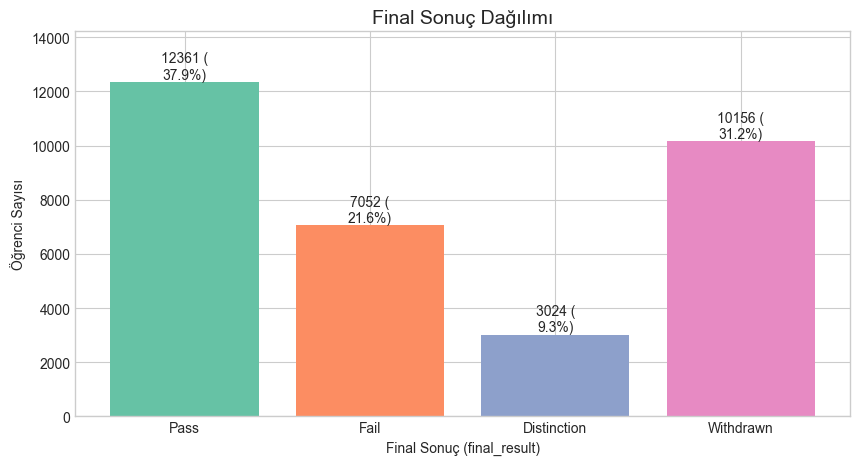

Kaydedildi: visuals/eda/hedef_degisken_dagilimi.png


In [14]:
# final_result dağılımı: sayı + yüzde etiketli bar chart

plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('visuals/eda', exist_ok=True)

final_order = ['Pass', 'Fail', 'Distinction', 'Withdrawn']

final_series = student_info['final_result'].astype(str).str.strip()
counts = final_series.value_counts(dropna=False)

# Sadece istenen sınıfları sıraya koy (eksikse 0)
counts_ordered = counts.reindex(final_order).fillna(0).astype(int)

total = counts_ordered.sum() if counts_ordered.sum() > 0 else 1
pct = counts_ordered / total * 100

palette = sns.color_palette('Set2', n_colors=len(final_order))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(final_order, counts_ordered.values, color=palette)

ax.set_title('Final Sonuç Dağılımı', fontsize=14)
ax.set_xlabel('Final Sonuç (final_result)')
ax.set_ylabel('Öğrenci Sayısı')

# Bar üstü etiketler: sayı + yüzde
for bar, c, p in zip(bars, counts_ordered.values, pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{c} (\n{p:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=10
    )

ax.set_ylim(0, max(counts_ordered.values) * 1.15 + 1)

out_path = 'visuals/eda/hedef_degisken_dagilimi.png'
fig.savefig(out_path, dpi=200, bbox_inches='tight')
plt.show()

print(f'Kaydedildi: {out_path}')


**Kısa yorum:** `final_result` dağılımı sınıflar arası dengesizse (ör. Withdrawn çok yüksekse), modelleme aşamasında sınıf dengesizliği ve metrik seçimi (F1, balanced accuracy vb.) kritik hale gelir.

### 8.2 Demografik Değişken Dağılımları (2x2 Subplot)
Aşağıdaki değişkenler için 2x2 subplot içinde bar chart çiziyoruz:
- `gender`
- `highest_education`
- `age_band`
- `disability`

Çıktı görseli: `visuals/eda/demografik_dagilimlar.png`

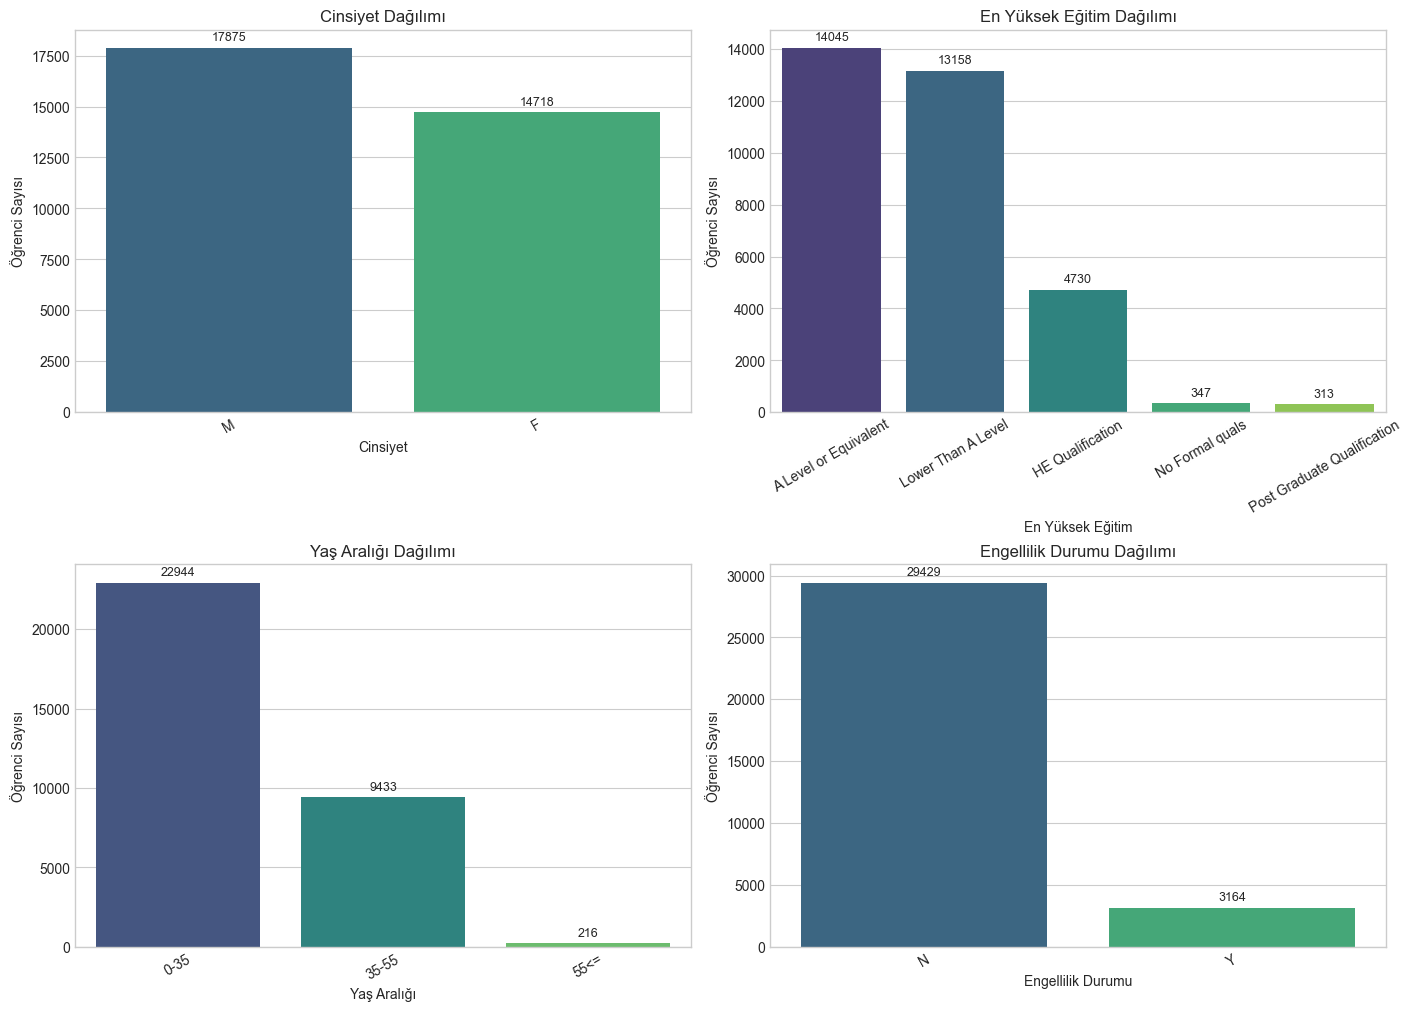

Kaydedildi: visuals/eda/demografik_dagilimlar.png


In [15]:
# 2x2 subplot: demografik değişken dağılımları

plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('visuals/eda', exist_ok=True)

vars_ = ['gender', 'highest_education', 'age_band', 'disability']
labels_tr = {
    'gender': 'Cinsiyet',
    'highest_education': 'En Yüksek Eğitim',
    'age_band': 'Yaş Aralığı',
    'disability': 'Engellilik Durumu'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axes = axes.ravel()

for ax, col in zip(axes, vars_):
    s = student_info[col]

    # Eksikleri de görünür kıl
    s_plot = s.astype(str).where(~s.isna(), other='Eksik')

    vc = s_plot.value_counts(dropna=False)

    sns.barplot(
        x=vc.index,
        y=vc.values,
        ax=ax,
        palette='viridis'
    )

    ax.set_title(f"{labels_tr.get(col, col)} Dağılımı")
    ax.set_xlabel(labels_tr.get(col, col))
    ax.set_ylabel('Öğrenci Sayısı')

    ax.tick_params(axis='x', rotation=30)

    # Bar üstü sadece sayı yaz (kalabalık olmaması için)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f', padding=3, fontsize=9)

out_path = 'visuals/eda/demografik_dagilimlar.png'
fig.savefig(out_path, dpi=200, bbox_inches='tight')
plt.show()

print(f'Kaydedildi: {out_path}')


**Kısa yorum:** Bu dağılımlar örneklemin demografik yapısını özetler. Bazı kategoriler çok düşük frekanstaysa, ileride kategorileri birleştirmek veya nadir sınıfları dikkatli ele almak (overfitting riskini azaltmak) faydalı olabilir.

### 8.3 Cinsiyet ve final_result İlişkisi
Cinsiyete göre `final_result` dağılımını **grouped bar chart** olarak çiziyoruz:
- x ekseni: `gender`
- renk (hue): `final_result`

Çıktı görseli: `visuals/eda/cinsiyet_basari.png`

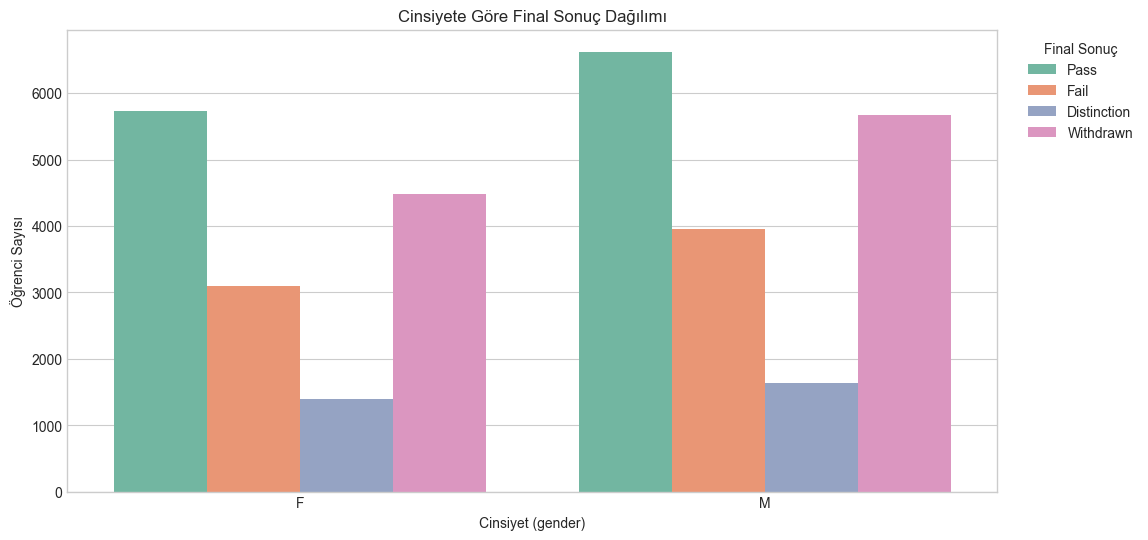

Kaydedildi: visuals/eda/cinsiyet_basari.png


In [16]:
# Grouped bar chart: gender x final_result

plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('visuals/eda', exist_ok=True)

final_order = ['Pass', 'Fail', 'Distinction', 'Withdrawn']

df_plot = student_info[['gender', 'final_result']].copy()
df_plot['gender'] = df_plot['gender'].astype(str).str.strip().where(~df_plot['gender'].isna(), other='Eksik')
df_plot['final_result'] = df_plot['final_result'].astype(str).str.strip().where(~df_plot['final_result'].isna(), other='Eksik')

# X ekseni için tipik sıra: F, M (varsa)
gender_order = [g for g in ['F', 'M'] if g in df_plot['gender'].unique()]
# farklı değer varsa sona ekle
for g in sorted(set(df_plot['gender'].unique()) - set(gender_order)):
    gender_order.append(g)

fig, ax = plt.subplots(figsize=(12, 6))

sns.countplot(
    data=df_plot,
    x='gender',
    hue='final_result',
    order=gender_order,
    hue_order=[c for c in final_order if c in df_plot['final_result'].unique()],
    palette='Set2',
    ax=ax
)

ax.set_title('Cinsiyete Göre Final Sonuç Dağılımı')
ax.set_xlabel('Cinsiyet (gender)')
ax.set_ylabel('Öğrenci Sayısı')
ax.legend(title='Final Sonuç', bbox_to_anchor=(1.02, 1), loc='upper left')

out_path = 'visuals/eda/cinsiyet_basari.png'
fig.savefig(out_path, dpi=200, bbox_inches='tight')
plt.show()

print(f'Kaydedildi: {out_path}')


**Kısa yorum:** Cinsiyet grupları arasında belirli `final_result` sınıflarında belirgin farklar varsa, bu durum cinsiyetin başarıyla ilişkili olabileceğine işaret eder. Ancak bu ilişkiyi yorumlarken örneklem büyüklükleri ve diğer demografik değişkenler (confounder) de dikkate alınmalıdır.

## 9. Modül / Yıl / Sosyoekonomik Gösterge Bazında Başarı Analizi
Bu bölümde `student_info` tablosundaki hedef değişken (`final_result`) dağılımını;
- **modül** (`code_module`),
- **sunum dönemi / yıl** (`code_presentation`),
- **sosyoekonomik gösterge** (`imd_band`)
 kırılımlarında inceliyoruz.

Not: Oranları daha okunabilir kılmak için bazı grafiklerde yığılmış (stacked) bar chart kullanıyoruz.

### 9.1 Modül Bazında Başarı Oranları (code_module)
Her modül için `final_result` sınıflarının **oranını** (satır bazında normalize) hesaplayıp **stacked bar chart** ile gösteriyoruz.

Çıktı görseli: `visuals/eda/modul_basari_oranlari.png`

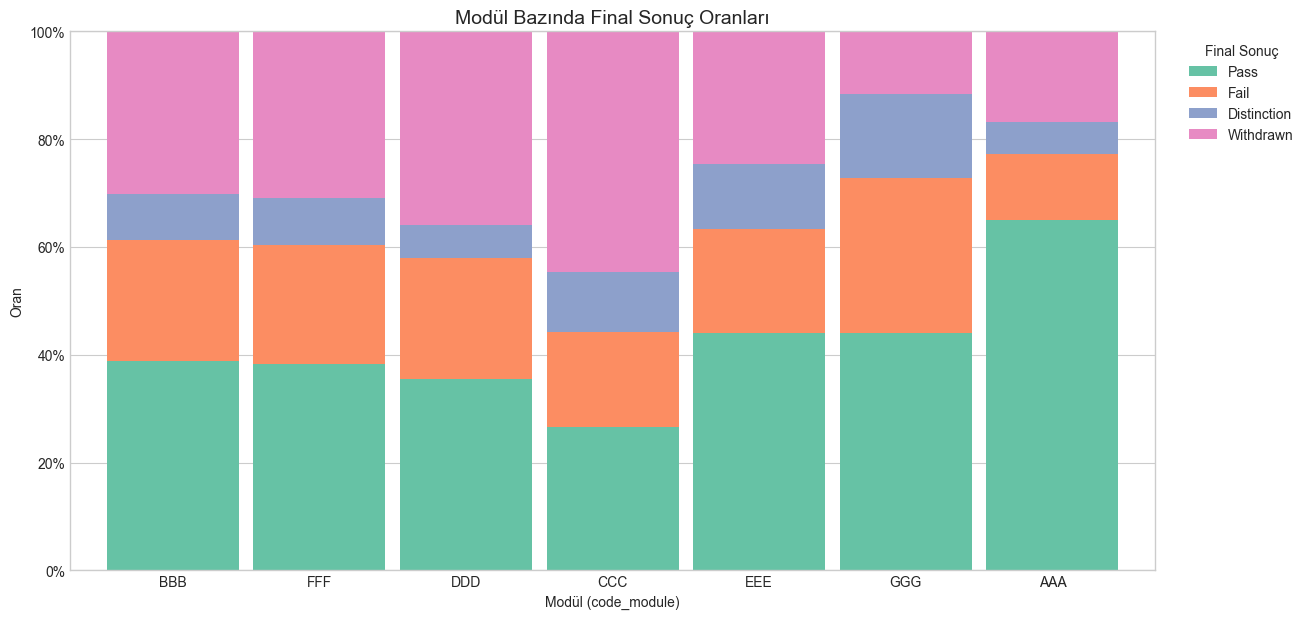

Kaydedildi: visuals/eda/modul_basari_oranlari.png


In [20]:
# Modül bazında final_result oranları (stacked)

plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('visuals/eda', exist_ok=True)

final_order = ['Pass', 'Fail', 'Distinction', 'Withdrawn']

df_mod = student_info[['code_module', 'final_result']].copy()
df_mod['code_module'] = df_mod['code_module'].astype(str).str.strip().where(~df_mod['code_module'].isna(), other='Eksik')
df_mod['final_result'] = df_mod['final_result'].astype(str).str.strip().where(~df_mod['final_result'].isna(), other='Eksik')

# Oran tablosu: her modül satırında sınıf oranları
ratio = pd.crosstab(df_mod['code_module'], df_mod['final_result'], normalize='index')

# İstenen sınıfları sıraya koy (eksik sınıf varsa 0 ekle)
for cls in final_order:
    if cls not in ratio.columns:
        ratio[cls] = 0.0
ratio = ratio[final_order]

# Modülleri gözlem sayısına göre sırala (çok küçük modüller en alta gelsin)
module_counts = df_mod['code_module'].value_counts()
ratio = ratio.loc[module_counts.index]

colors = sns.color_palette('Set2', n_colors=len(final_order))

fig, ax = plt.subplots(figsize=(14, 7))
ratio.plot(kind='bar', stacked=True, ax=ax, color=colors, width=0.9)

ax.set_title('Modül Bazında Final Sonuç Oranları', fontsize=14)
ax.set_xlabel('Modül (code_module)')
ax.set_ylabel('Oran')
ax.set_ylim(0, 1)

# Y eksenini yüzde olarak göster
ax.yaxis.set_major_formatter(lambda x, pos: f"{x*100:.0f}%")

ax.legend(title='Final Sonuç', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)

out_path = 'visuals/eda/modul_basari_oranlari.png'
fig.savefig(out_path, dpi=200, bbox_inches='tight')
plt.show()

print(f'Kaydedildi: {out_path}')


**Kısa yorum:** Modüller arasında başarının (Pass/Distinction) ve başarısızlığın/çekilmenin (Fail/Withdrawn) oranları belirgin farklılaşıyorsa, modül bilgisi güçlü bir açıklayıcı değişken olabilir. Ancak modül büyüklükleri (örnek sayısı) çok farklıysa oranları örnek sayısıyla birlikte değerlendirmek gerekir.

### 9.2 Yıl / Sunum Dönemi (code_presentation) Bazında Başarı Dağılımı
`code_presentation` (örn. 2013J, 2014B gibi) kırılımında `final_result` dağılımını bar chart ile gösteriyoruz.

Çıktı görseli: `visuals/eda/yil_basari_dagilimi.png`

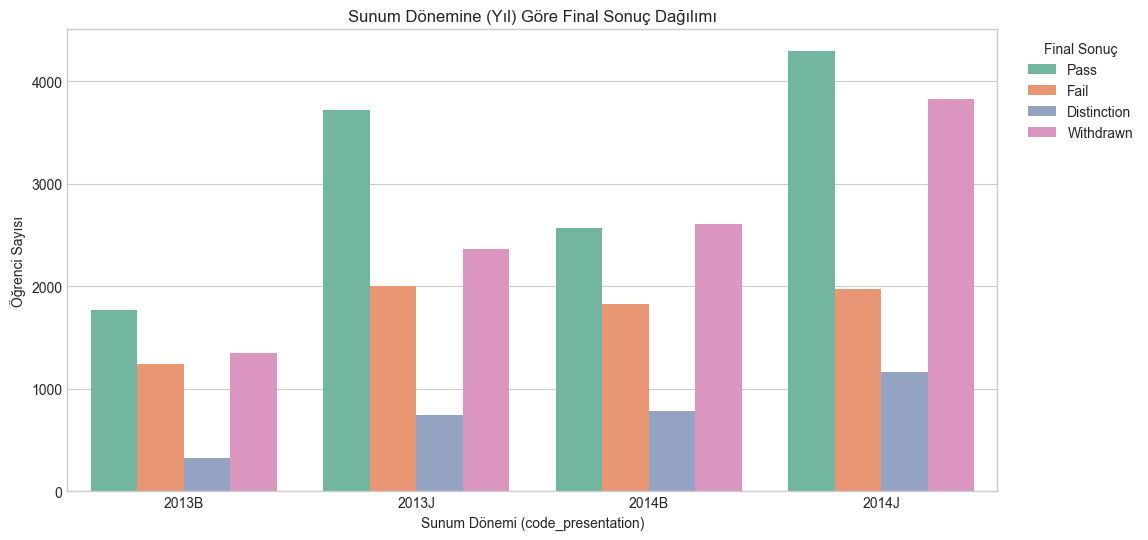

Kaydedildi: visuals/eda/yil_basari_dagilimi.png


In [21]:
# code_presentation bazında final_result dağılımı (bar chart)

plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('visuals/eda', exist_ok=True)

final_order = ['Pass', 'Fail', 'Distinction', 'Withdrawn']

df_year = student_info[['code_presentation', 'final_result']].copy()
df_year['code_presentation'] = df_year['code_presentation'].astype(str).str.strip().where(~df_year['code_presentation'].isna(), other='Eksik')
df_year['final_result'] = df_year['final_result'].astype(str).str.strip().where(~df_year['final_result'].isna(), other='Eksik')

# code_presentation genelde '2013J' gibi olduğundan leksikografik sıralama iş görür
presentation_order = sorted(df_year['code_presentation'].unique())

fig, ax = plt.subplots(figsize=(12, 6))

sns.countplot(
    data=df_year,
    x='code_presentation',
    hue='final_result',
    order=presentation_order,
    hue_order=[c for c in final_order if c in df_year['final_result'].unique()],
    palette='Set2',
    ax=ax
)

ax.set_title('Sunum Dönemine (Yıl) Göre Final Sonuç Dağılımı')
ax.set_xlabel('Sunum Dönemi (code_presentation)')
ax.set_ylabel('Öğrenci Sayısı')
ax.legend(title='Final Sonuç', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)

out_path = 'visuals/eda/yil_basari_dagilimi.png'
fig.savefig(out_path, dpi=200, bbox_inches='tight')
plt.show()

print(f'Kaydedildi: {out_path}')


**Kısa yorum:** Dönemler arasında Withdrawn/Fail oranları artıp azalabiliyorsa, belirli yıllarda/dönemlerde ders içeriği, değerlendirme zorluğu veya öğrenci profili değişmiş olabilir. Bu tür dönem etkileri modelleme için önemli bir sinyal olabilir.

### 9.3 imd_band ile final_result İlişkisi
`imd_band` sosyoekonomik göstergesini (yüzdelik dilimler) doğru sıra ile ele alıp `final_result` ile ilişkisini görselleştiriyoruz.

Bu grafikte **stacked bar chart** ile her `imd_band` grubunda final sonuçların **oranını** gösteriyoruz.

Çıktı görseli: `visuals/eda/imd_basari_iliskisi.png`

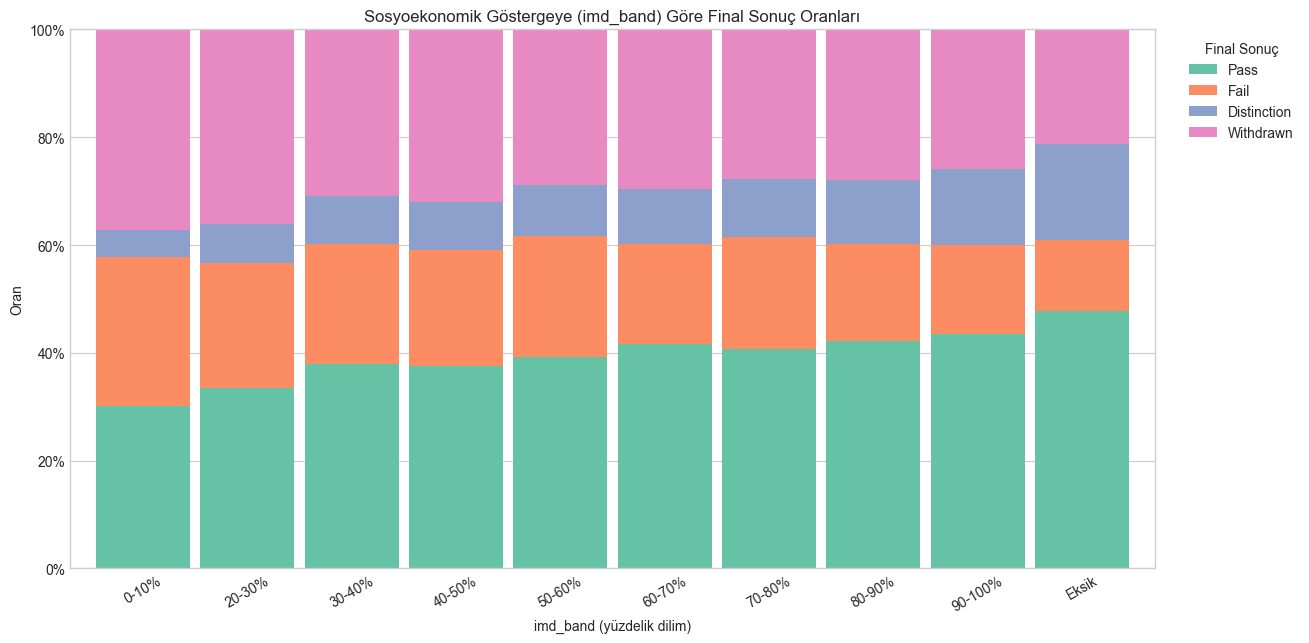

Kaydedildi: visuals/eda/imd_basari_iliskisi.png


In [22]:
# imd_band (sosyoekonomik gösterge) x final_result ilişkisi

plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('visuals/eda', exist_ok=True)

final_order = ['Pass', 'Fail', 'Distinction', 'Withdrawn']
imd_order = [
    '0-10%', '10-20%', '20-30%', '30-40%', '40-50%',
    '50-60%', '60-70%', '70-80%', '80-90%', '90-100%'
]

df_imd = student_info[['imd_band', 'final_result']].copy()
df_imd['imd_band'] = df_imd['imd_band'].astype(str).str.strip().where(~df_imd['imd_band'].isna(), other='Eksik')
df_imd['final_result'] = df_imd['final_result'].astype(str).str.strip().where(~df_imd['final_result'].isna(), other='Eksik')

# Kategorik sıra uygula (Eksik en sona)
cat_order = [c for c in imd_order if c in df_imd['imd_band'].unique()]
if 'Eksik' in df_imd['imd_band'].unique():
    cat_order = cat_order + ['Eksik']
else:
    # imd_band beklenmedik etiketler içeriyorsa sona ekle
    extra = sorted(set(df_imd['imd_band'].unique()) - set(cat_order))
    cat_order = cat_order + extra

df_imd['imd_band'] = pd.Categorical(df_imd['imd_band'], categories=cat_order, ordered=True)

ratio = pd.crosstab(df_imd['imd_band'], df_imd['final_result'], normalize='index')

for cls in final_order:
    if cls not in ratio.columns:
        ratio[cls] = 0.0
ratio = ratio[final_order]

colors = sns.color_palette('Set2', n_colors=len(final_order))

fig, ax = plt.subplots(figsize=(14, 7))
ratio.plot(kind='bar', stacked=True, ax=ax, color=colors, width=0.9)

ax.set_title('Sosyoekonomik Göstergeye (imd_band) Göre Final Sonuç Oranları')
ax.set_xlabel('imd_band (yüzdelik dilim)')
ax.set_ylabel('Oran')
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(lambda x, pos: f"{x*100:.0f}%")
ax.legend(title='Final Sonuç', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=30)

out_path = 'visuals/eda/imd_basari_iliskisi.png'
fig.savefig(out_path, dpi=200, bbox_inches='tight')
plt.show()

print(f'Kaydedildi: {out_path}')


**Kısa yorum:** Eğer üst gelir dilimlerinde Pass/Distinction oranı artıyor (veya Withdrawn azalıyor) gibi bir eğilim görülüyorsa, sosyoekonomik durum ile başarı arasında bir ilişki olabileceğini düşündürür. Bu tür ilişkiler nedensellik göstermez; ancak modelleme ve eşitlik/fairness değerlendirmeleri için önemli bir bulgudur.

## 10. VLE ve Assessment Analizi (Etkileşim ve Skorlar)
Bu bölümde:
- `student_vle` üzerinden öğrenci başına toplam tıklama (sum_click) hesaplayıp dağılımını inceliyoruz,
- `student_info` ile birleştirip (final_result) başarı durumuna göre tıklama farklılıklarını boxplot ile gösteriyoruz,
- `student_assessment` üzerinden skor dağılımını ve bazı özet metrikleri görselleştiriyoruz.

Tüm görseller `seaborn-v0_8-whitegrid` stiliyle üretilir ve `visuals/eda/` klasörüne kaydedilir.

### 10.1 VLE — Öğrenci Başına Toplam Tıklama Dağılımı
Önce `student_vle` tablosunda öğrenci bazında `sum_click` değerlerini toplayıp toplam tıklama değişkenini elde ediyoruz.
Dağılımı histogram ile gösterirken, aşırı büyük değerlerin grafiği bozmaması için x eksenini yüzde 99 persentile göre kırpıyoruz.

Çıktı görseli: `visuals/eda/vle_tiklama_dagilimi.png`

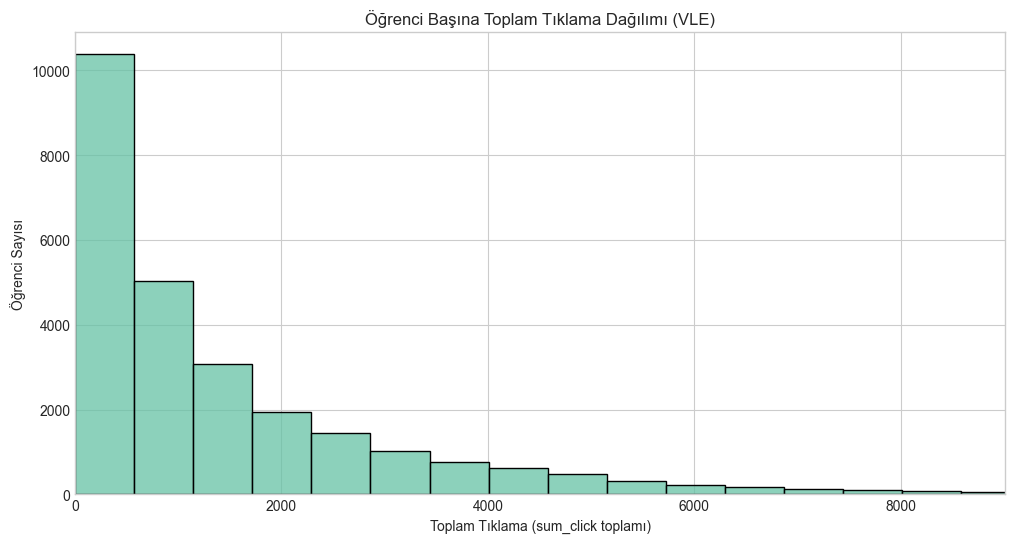

Kaydedildi: visuals/eda/vle_tiklama_dagilimi.png


In [28]:
# VLE: öğrenci başına toplam tıklama + histogram

plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('visuals/eda', exist_ok=True)

# 1) Öğrenci başına toplam tıklama
vle_clicks = (
    student_vle
    .groupby('id_student', as_index=False)['sum_click']
    .sum()
    .rename(columns={'sum_click': 'toplam_tiklama'})
)

# Histogram için seri
clicks = vle_clicks['toplam_tiklama'].astype(float)

# Aykırı değerleri grafikte kesmek için (xlim): 99. persentil
x_max = float(clicks.quantile(0.99)) if len(clicks) else 1.0
x_max = max(x_max, 1.0)

fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(clicks, bins=50, kde=False, ax=ax, color=sns.color_palette('Set2')[0])
ax.set_title('Öğrenci Başına Toplam Tıklama Dağılımı (VLE)')
ax.set_xlabel('Toplam Tıklama (sum_click toplamı)')
ax.set_ylabel('Öğrenci Sayısı')
ax.set_xlim(0, x_max)

out_path = 'visuals/eda/vle_tiklama_dagilimi.png'
fig.savefig(out_path, dpi=200, bbox_inches='tight')
plt.show()

print(f'Kaydedildi: {out_path}')


**Kısa yorum:** Tıklama dağılımı genellikle sağa çarpıktır; az sayıda öğrenci çok yüksek etkileşime sahip olabilir. Bu yüzden modelleme aşamasında log-dönüşüm veya winsorization gibi yaklaşımlar düşünülebilir.

### 10.2 VLE — Başarı Durumuna Göre Toplam Tıklama (Boxplot)
Toplam tıklama verisini `student_info` ile birleştirip `final_result` sınıflarına göre boxplot çiziyoruz.

Çıktı görseli: `visuals/eda/vle_basari_boxplot.png`

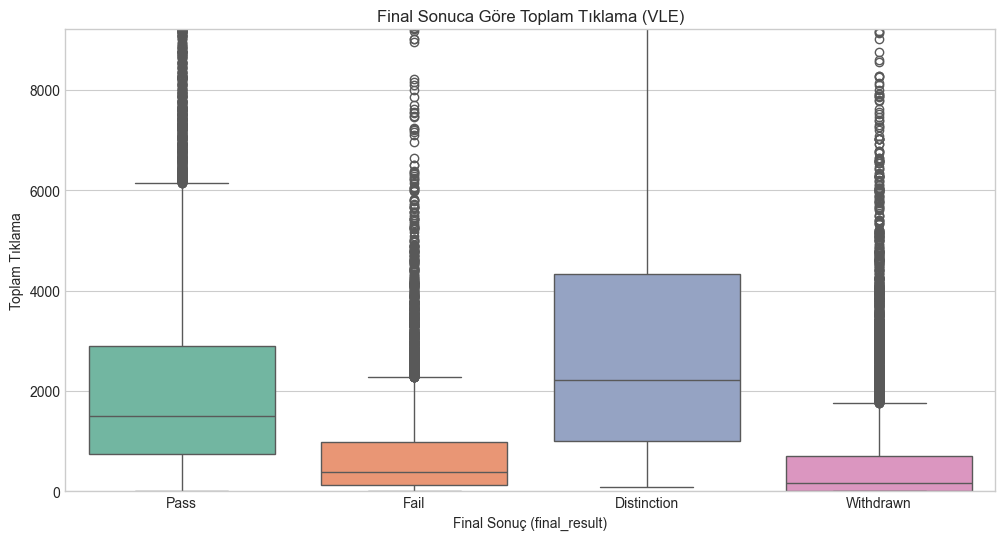

Kaydedildi: visuals/eda/vle_basari_boxplot.png


In [29]:
# VLE: final_result'a göre toplam tıklama boxplot

plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('visuals/eda', exist_ok=True)

final_order = ['Pass', 'Fail', 'Distinction', 'Withdrawn']

# Öğrenci bazında tıklamayı final_result ile birleştir
clicks_with_result = (
    student_info[['id_student', 'final_result']]
    .merge(vle_clicks, on='id_student', how='left')
)
clicks_with_result['toplam_tiklama'] = clicks_with_result['toplam_tiklama'].fillna(0)

# Sadece beklenen sınıflar
plot_df = clicks_with_result[clicks_with_result['final_result'].isin(final_order)].copy()

# Boxplot okunabilirliği için üst sınırı 99. persentile göre kırp (grafikte)
y_max = float(plot_df['toplam_tiklama'].quantile(0.99)) if len(plot_df) else 1.0
y_max = max(y_max, 1.0)

fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=plot_df,
    x='final_result',
    y='toplam_tiklama',
    order=final_order,
    palette='Set2',
    ax=ax
)

ax.set_title('Final Sonuca Göre Toplam Tıklama (VLE)')
ax.set_xlabel('Final Sonuç (final_result)')
ax.set_ylabel('Toplam Tıklama')
ax.set_ylim(0, y_max)

out_path = 'visuals/eda/vle_basari_boxplot.png'
fig.savefig(out_path, dpi=200, bbox_inches='tight')
plt.show()

print(f'Kaydedildi: {out_path}')


**Kısa yorum:** Eğer Pass/Distinction gruplarında tıklama medyanı daha yüksekse, VLE etkileşimi ile başarı arasında pozitif bir ilişki olabilir. Withdrawn grubunda düşük etkileşim görülmesi, erken bırakma davranışını yansıtıyor olabilir.

### 10.3 Assessment — Skor Dağılımı (Histogram)
`student_assessment` tablosundaki `score` değişkeninin dağılımını histogram ile inceliyoruz.

Çıktı görseli: `visuals/eda/skor_dagilimi.png`

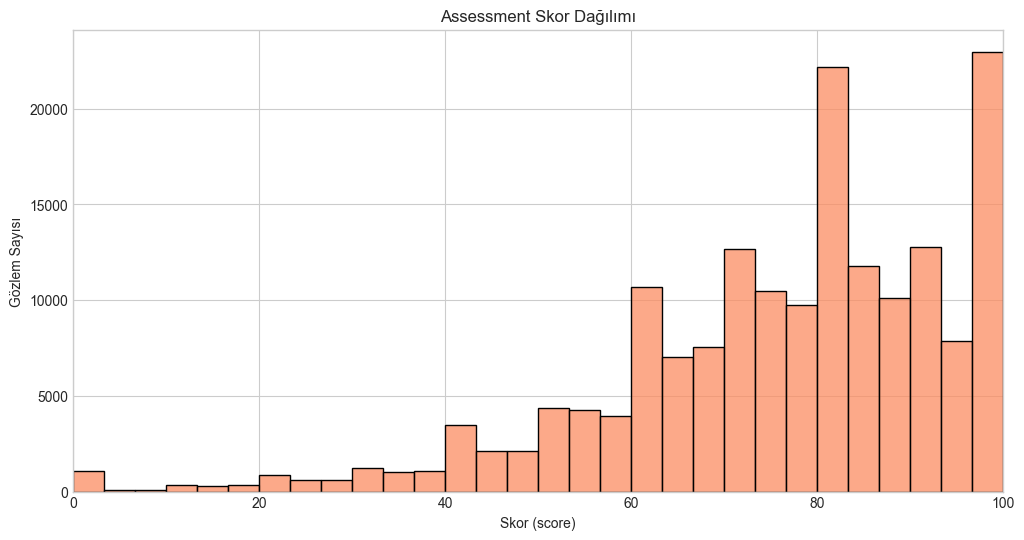

Kaydedildi: visuals/eda/skor_dagilimi.png


In [30]:
# Assessment: skor dağılımı (histogram)

plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('visuals/eda', exist_ok=True)

scores = student_assessment['score'].dropna().astype(float)

# Skorlar genelde 0-100 aralığında; yine de aykırılar için 99. persentil ile kırp
x_max = float(scores.quantile(0.99)) if len(scores) else 100.0
x_max = max(min(x_max, 100.0), 1.0)

fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(scores, bins=30, ax=ax, color=sns.color_palette('Set2')[1])
ax.set_title('Assessment Skor Dağılımı')
ax.set_xlabel('Skor (score)')
ax.set_ylabel('Gözlem Sayısı')
ax.set_xlim(0, x_max)

out_path = 'visuals/eda/skor_dagilimi.png'
fig.savefig(out_path, dpi=200, bbox_inches='tight')
plt.show()

print(f'Kaydedildi: {out_path}')


**Kısa yorum:** Skor dağılımı tek tepe/duble tepe gibi bir yapı gösteriyorsa, değerlendirmelerin zorluk seviyesi veya farklı assessment tipleri (TMA, CMA, Exam) bu yapıyı etkiliyor olabilir.

### 10.4 Assessment — Geç Teslim Oranı (is_banked)
Bu adımda `is_banked` sütununu kullanarak geç teslim oranını özetliyoruz.

Not: OULAD açıklamalarında `is_banked` alanı farklı bir anlama gelebilir; burada istenen şekilde **geç teslim için gösterge** olarak ele alıyoruz.

Çıktı görseli: `visuals/eda/gec_teslim_orani.png`

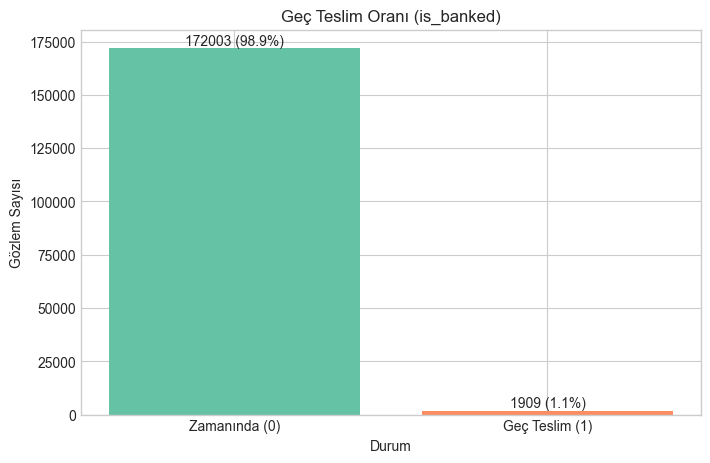

Kaydedildi: visuals/eda/gec_teslim_orani.png


In [31]:
# is_banked üzerinden geç teslim oranı (bar chart)

plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('visuals/eda', exist_ok=True)

banked = student_assessment['is_banked'].fillna(0).astype(int)
counts = banked.value_counts().reindex([0, 1]).fillna(0).astype(int)

total = int(counts.sum()) if int(counts.sum()) > 0 else 1
pct = counts / total * 100

labels = ['Zamanında (0)', 'Geç Teslim (1)']
values = counts.values
colors = sns.color_palette('Set2', n_colors=2)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=colors)

ax.set_title('Geç Teslim Oranı (is_banked)')
ax.set_xlabel('Durum')
ax.set_ylabel('Gözlem Sayısı')

for bar, c, p in zip(bars, values, pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{c} ({p:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=10
    )

out_path = 'visuals/eda/gec_teslim_orani.png'
fig.savefig(out_path, dpi=200, bbox_inches='tight')
plt.show()

print(f'Kaydedildi: {out_path}')


**Kısa yorum:** Geç teslim oranı yüksekse, öğrencilerin zaman yönetimi/katılım problemi olabileceğini gösterebilir ve başarıyla ilişkili olabilecek önemli bir davranışsal sinyaldir.

### 10.5 Assessment — final_result'a Göre Ortalama Skor
`student_assessment` ile `student_info` tablolarını öğrenci ID üzerinden birleştirip final sonuca göre ortalama skoru hesaplıyoruz.

Çıktı görseli: `visuals/eda/sonuca_gore_ortalama_skor.png`

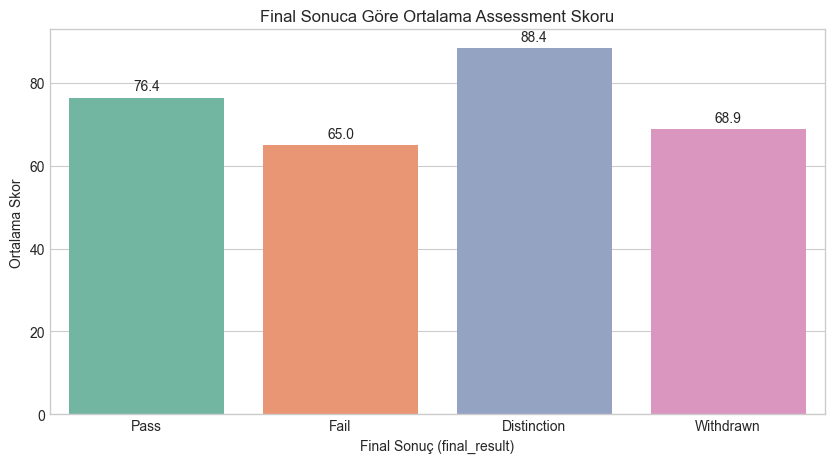

Kaydedildi: visuals/eda/sonuca_gore_ortalama_skor.png


In [32]:
# final_result'a göre ortalama skor (bar chart)

plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('visuals/eda', exist_ok=True)

final_order = ['Pass', 'Fail', 'Distinction', 'Withdrawn']

assm = student_assessment[['id_student', 'score']].copy()
assm['score'] = pd.to_numeric(assm['score'], errors='coerce')

merged = assm.merge(student_info[['id_student', 'final_result']], on='id_student', how='left')
merged = merged[merged['final_result'].isin(final_order) & merged['score'].notna()].copy()

mean_score = (
    merged
    .groupby('final_result', as_index=False)['score']
    .mean()
    .rename(columns={'score': 'ortalama_skor'})
)

# Sıralı göster
mean_score['final_result'] = pd.Categorical(mean_score['final_result'], categories=final_order, ordered=True)
mean_score = mean_score.sort_values('final_result')

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=mean_score,
    x='final_result',
    y='ortalama_skor',
    order=final_order,
    palette='Set2',
    ax=ax
)

ax.set_title('Final Sonuca Göre Ortalama Assessment Skoru')
ax.set_xlabel('Final Sonuç (final_result)')
ax.set_ylabel('Ortalama Skor')

# Bar üstü değer etiketleri
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=10)

out_path = 'visuals/eda/sonuca_gore_ortalama_skor.png'
fig.savefig(out_path, dpi=200, bbox_inches='tight')
plt.show()

print(f'Kaydedildi: {out_path}')


**Kısa yorum:** Ortalama skorun Pass/Distinction gruplarında daha yüksek olması beklenir. Fail/Withdrawn gruplarında düşük ortalama skor görülmesi, süreç içinde erken kopma veya düşük değerlendirme performansına işaret edebilir.

## 11. EDA Özeti (OULAD)

> **Not:** Modelleme açısından ana birim **öğrenci** olup, hedef değişken `student_info.final_result` üzerinden ele alınmıştır.

### İncelenen veri kapsamı
Bu EDA kapsamında OULAD’ın aşağıdaki tabloları incelenmiştir:

| Tablo | Kayıt (satır) | Değişken (sütun) |
|---|---:|---:|
| courses | 22 | 3 |
| assessments | 206 | 6 |
| vle | 6.364 | 6 |
| student_info | 32.593 | 12 |
| student_registration | 32.593 | 5 |
| student_assessment | 173.912 | 5 |
| student_vle | 10.655.280 | 6 |

### En önemli bulgular (5–6 madde)
- **Hedef dağılımı (`final_result`) dengesiz:** Pass **12.361 (~%37,9)**, Withdrawn **10.156 (~%31,2)**, Fail **7.052 (~%21,6)**, Distinction **3.024 (~%9,3)**.
- **Eksik veri belirli alanlarda yoğun:** `vle.week_from/week_to` alanları **~%82,39** eksik; `student_registration.date_unregistration` **~%69,10** eksik.
- `student_info.imd_band` **~%3,41** eksik; `assessments.date` **~%5,34** eksik; `student_assessment.score` eksikleri **çok düşük (~%0,10)**.
- `student_assessment.is_banked=1` oranı **~%1,10** ile oldukça düşük; nadir bir durum/sinyal olarak ele alınmalı.
- Ortalama assessment skoru hedef sınıflarıyla tutarlı: **Distinction (~88,40) > Pass (~76,41) > Withdrawn (~68,87) > Fail (~64,95)**.
- VLE etkileşimi (toplam tıklama) dağılımı **sağa çarpık**; başarı grupları arasında tıklama seviyeleri farklılaşabiliyor (özellikle Withdrawn ayrışabilir).

### Ön işlemede ele alınması gereken değişkenler
- **Eksikler:** `vle.week_from`, `vle.week_to`, `student_registration.date_unregistration`, `assessments.date`, `student_info.imd_band` (uygun imputasyon/iş kuralı).
- **Kategorikler:** `gender`, `region`, `highest_education`, `age_band`, `disability`, `imd_band`, `code_module`, `code_presentation` (encoding/rare category stratejisi).
- **Aykırı değer / çarpıklık:** `student_vle.sum_click` → öğrenci bazında toplam tıklama türetilip log-dönüşüm / winsorization düşünülebilir.
- **Sınıf dengesizliği:** `final_result` için stratified split, uygun metrikler (macro-F1 vb.) ve gerekiyorsa class weighting.
- **Birleştirme & agregasyon:** `student_vle` ve `student_assessment` öğrenci bazına indirgenerek (toplam/ortalama/kaç adet vb.) `student_info` ile birleştirilmelidir.

### Modelleme için öne çıkan değişkenler (aday özellikler)
- **Davranışsal:** öğrenci bazında toplam tıklama, tıklama çeşitliliği (site türleri), dönem içi aktivite yoğunluğu.
- **Performans:** assessment skorlarının ortalaması/medyanı, alınan assessment sayısı, zamanında/geç durum göstergeleri (`is_banked`).
- **Demografi & bağlam:** `highest_education`, `age_band`, `imd_band`, `disability`, `region`, `code_module`, `code_presentation`.

In [35]:
# Üretilen görselleri listele ve sayısını yazdır
import os

eda_dir = 'visuals/eda'

if not os.path.isdir(eda_dir):
    print(f'Klasör bulunamadı: {eda_dir}')
else:
    files = sorted(os.listdir(eda_dir))
    print('Üretilen görsel dosyaları (visuals/eda/):')
    for f in files:
        print('-', f)

    # Görsel sayısını uzantı bazında say (EDA çıktıları ağırlıkla PNG)
    img_ext = ('.png', '.jpg', '.jpeg', '.svg', '.pdf')
    img_files = [f for f in files if f.lower().endswith(img_ext)]
    print(f"\nToplam görsel sayısı: {len(img_files)}")

Üretilen görsel dosyaları (visuals/eda/):
- cinsiyet_basari.png
- demografik_dagilimlar.png
- eksik_veri_heatmap.png
- gec_teslim_orani.png
- hedef_degisken_dagilimi.png
- imd_basari_iliskisi.png
- modul_basari_oranlari.png
- skor_dagilimi.png
- sonuca_gore_ortalama_skor.png
- vle_basari_boxplot.png
- vle_tiklama_dagilimi.png
- yil_basari_dagilimi.png

Toplam görsel sayısı: 12


In [34]:
print("EDA tamamlandı. Sıradaki adım: Veri Ön İşleme (02_preprocessing.ipynb)")

EDA tamamlandı. Sıradaki adım: Veri Ön İşleme (02_preprocessing.ipynb)
